# MSFT Next-Day Direction Predictor — Iteration 2

**Author:** Lucan den Dekker
**Project:** ADSAI Group 15 Block D Capstone
**Date:** 2026-05-20

---

**Improvements over Iteration 1**

| Change | Reason |
|---|---|
| Absolute price features replaced with ratios / % | MSFT 10× price appreciation breaks stationarity |
| RSI(14), momentum_5, momentum_10, volume_ratio added | Classic technical indicators with documented predictive value |
| Monthly VIX (forward-filled) removed | Constant within each month — adds noise not signal |
| `class_weight='balanced'` on LR and RF | Corrects slight UP-class majority in training set |
| RF: `max_depth=6`, `min_samples_leaf=5` | Reduces overfitting on ~1000-row dataset |
| XGBoost: `subsample=0.8`, `colsample_bytree=0.8`, `scale_pos_weight` | Stochastic regularisation + explicit class balance |
| All pipeline steps wrapped in functions | Modularity, reuse, testability |
| PEP 8 alignment fixes | E221 (extra whitespace before `=`) removed |

| Section | Content |
|---|---|
| 0 | Imports and Setup |
| 1 | Load Data |
| 2 | Feature Engineering |
| 3 | Train/Test Split & Scaling |
| 4 | Baseline Model |
| 5 | Logistic Regression |
| 6 | Random Forest |
| 7 | XGBoost |
| 8 | Model Comparison |
| 9 | Error Analysis |
| 10 | TimeSeriesSplit Cross-Validation |
| 11 | Business Value Interpretation |


In [13]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost joblib

Note: you may need to restart the kernel to use updated packages.


---
## Section 0 — Imports and Setup

`RANDOM_SEED = 42` is applied to every stochastic component for full reproducibility.
`RobustScaler` is preferred over `StandardScaler` because financial returns contain
extreme outliers (e.g. COVID-19 crash) that distort standard-deviation normalisation.


In [14]:
# Standard library
import warnings
import logging
from pathlib import Path

# Scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

# Scikit-learn
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
)
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# XGBoost
from xgboost import XGBClassifier
import xgboost as xgb_lib

# Persistence
import joblib

# Reproducibility
RANDOM_SEED: int = 42
np.random.seed(RANDOM_SEED)
warnings.filterwarnings("ignore")

# Logging — timestamps + severity levels persist in saved notebook outputs
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S",
)
logger = logging.getLogger("msft_modelling")

# Plot style
try:
    plt.style.use("seaborn-v0_8-darkgrid")
except OSError:
    plt.style.use("seaborn-darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13


def find_project_root(marker: str = "README.md") -> Path:
    """Walk up the directory tree until a marker file is found.

    Parameters
    ----------
    marker : str
        Filename expected at the repository root.

    Returns
    -------
    Path
        Absolute path to the repository root.
    """
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    logger.warning("Project root not found; falling back to cwd.")
    return current


PROJECT_ROOT = find_project_root()
DATA_PATH = PROJECT_ROOT / "msft-forecaster" / "data" / "processed" / "msft_merged.csv"
MODELS_DIR = PROJECT_ROOT / "models" / "lucan"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

logger.info("Project root : %s", PROJECT_ROOT)
logger.info("Data path    : %s", DATA_PATH)
logger.info("Models dir   : %s", MODELS_DIR)


2026-05-20 16:49:58 | INFO | Project root : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15
2026-05-20 16:49:58 | INFO | Data path    : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\msft-forecaster\data\processed\msft_merged.csv
2026-05-20 16:49:58 | INFO | Models dir   : c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan


---
## Section 1 — Load Data

`load_data` detects the date column case-insensitively and returns a `DatetimeIndex`
sorted ascending. Rows with missing values are dropped before any feature computation
so that rolling/lag operations produce deterministic results.

Data is restricted to 2019-01-01 onwards to keep the model focused on the
current market regime and avoid noise from structurally different pre-2019 conditions.


In [15]:
def load_data(path: Path) -> pd.DataFrame:
    """Load the MSFT merged CSV and return a date-indexed DataFrame.

    Parameters
    ----------
    path : Path
        Absolute path to the CSV file.

    Returns
    -------
    pd.DataFrame
        DataFrame with a DatetimeIndex sorted ascending.

    Raises
    ------
    FileNotFoundError
        If the CSV file does not exist.
    ValueError
        If no date column is detected.
    """
    if not path.exists():
        raise FileNotFoundError(f"Data file not found: {path}")

    df = pd.read_csv(path)

    # Detect date column regardless of capitalisation
    date_col = next(
        (c for c in df.columns if c.lower() in ("date", "datetime", "timestamp")),
        None,
    )
    if date_col is None:
        raise ValueError(f"No date column found. Columns: {list(df.columns)}")

    df[date_col] = pd.to_datetime(df[date_col])
    df.set_index(date_col, inplace=True)
    df.index.name = "Date"
    df.sort_index(inplace=True)
    return df


df_raw = load_data(DATA_PATH)
logger.info(
    "Loaded: shape=%s | %s to %s",
    df_raw.shape,
    df_raw.index.min().date(),
    df_raw.index.max().date(),
)

missing = int(df_raw.isnull().sum().sum())
if missing > 0:
    logger.warning("%d missing values found; dropping affected rows.", missing)
    df_raw = df_raw.dropna()
else:
    logger.info("No missing values found.")

# Restrict to post-2019 to keep features relevant to the current market regime
CUTOFF_DATE = pd.Timestamp("2019-01-01")
rows_before = len(df_raw)
df_raw = df_raw.loc[df_raw.index >= CUTOFF_DATE]
logger.info(
    "Pre-2019 rows dropped: %d | kept: %d",
    rows_before - len(df_raw),
    len(df_raw),
)
print(df_raw.head())


2026-05-20 16:49:58 | INFO | Loaded: shape=(2818, 8) | 2015-02-17 to 2026-04-30
2026-05-20 16:49:58 | INFO | No missing values found.
2026-05-20 16:49:58 | INFO | Pre-2019 rows dropped: 976 | kept: 1842


              Open      High       Low   Close      Volume   gold_close  \
Date                                                                      
2019-01-02   99.55  101.7500   98.9400  101.12  35329345.0  1281.000000   
2019-01-03  100.10  100.1850   97.2000   97.40  42578410.0  1291.800049   
2019-01-04   99.72  102.5100   98.9300  101.93  44060590.0  1282.699951   
2019-01-07  101.64  103.2681  100.9800  102.06  35656136.0  1286.800049   
2019-01-08  103.04  103.9700  101.7134  102.80  31514415.0  1283.199951   

            oil_close        vix  
Date                              
2019-01-02  46.540001  23.219999  
2019-01-03  47.090000  25.450001  
2019-01-04  47.959999  21.379999  
2019-01-07  48.520000  21.400000  
2019-01-08  49.779999  20.469999  


---
## Section 2 — Feature Engineering

**Key change from Iteration 1:** absolute price features (`lag_close_1`,
`rolling_mean_5`, etc.) are replaced with *scale-invariant* equivalents.
MSFT's close price grew from ~$45 in 2015 to ~$400 in 2025 — a 10× increase.
Models trained on absolute prices learn a non-stationary distribution and
generalise poorly to price levels unseen during training.

| Feature | Type | Description |
|---|---|---|
| `rsi_14` | Momentum oscillator | Overbought/oversold signal (0–100) |
| `momentum_5` | 5-day return % | Short-term price momentum |
| `momentum_10` | 10-day return % | Medium-term price momentum |
| `daily_return` | 1-day return % | Today's intraday direction |
| `price_range_pct` | Volatility | (High−Low)/Close — normalised intraday range |
| `close_to_sma5_pct` | Trend deviation | Distance from 5-day MA (%) |
| `close_to_sma10_pct` | Trend deviation | Distance from 10-day MA (%) |
| `sma_crossover` | Trend signal | SMA5/SMA10 — golden/death cross ratio |
| `rolling_std_5` | Volatility | 5-day rolling standard deviation |
| `volume_ratio` | Volume signal | Today's volume / 20-day average volume |
| `lag_gold_return` | Macro | Yesterday's gold % change |
| `lag_oil_return` | Macro | Yesterday's oil % change |

**Target:** next-day return > +0.5 % → UP (1), < −0.5 % → DOWN (0), neutral excluded.


In [16]:
def _detect_column(df: pd.DataFrame, candidates: list) -> str:
    """Return the first column name matching any candidate (case-insensitive).

    Parameters
    ----------
    df : pd.DataFrame
        Source dataframe.
    candidates : list of str
        Ordered list of expected column names (lowercase).

    Returns
    -------
    str
        The actual column name as it appears in df.

    Raises
    ------
    KeyError
        If none of the candidates match any column.
    """
    col_lower = {c.lower(): c for c in df.columns}
    for name in candidates:
        if name in col_lower:
            return col_lower[name]
    raise KeyError(f"None of {candidates} found in columns: {list(df.columns)}")


def _rsi(series: pd.Series, window: int = 14) -> pd.Series:
    """Compute RSI using Wilder's exponential smoothing.

    Values above 70 indicate overbought conditions (potential reversal down);
    values below 30 indicate oversold conditions (potential reversal up).

    Parameters
    ----------
    series : pd.Series
        Daily close price series.
    window : int
        Look-back period (standard: 14 trading days).

    Returns
    -------
    pd.Series
        RSI values in the range [0, 100].
    """
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=window - 1, min_periods=window).mean()
    avg_loss = loss.ewm(com=window - 1, min_periods=window).mean()
    rs = avg_gain / avg_loss
    return 100 - (100 / (1 + rs))


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add scale-invariant technical and macro features, plus binary target.

    All features use only data available at close on day t so there is
    no lookahead bias. Absolute price levels are replaced with ratio/
    percentage features to handle MSFT's 10x price appreciation.

    Parameters
    ----------
    df : pd.DataFrame
        Raw merged MSFT dataframe with a DatetimeIndex.

    Returns
    -------
    pd.DataFrame
        DataFrame with engineered features and integer 'target' column.
        Neutral days and NaN rows are dropped.
    """
    df = df.copy()

    close = df[_detect_column(df, ["close", "msft_close", "adj close", "adj_close"])]
    high = df[_detect_column(df, ["high", "msft_high"])]
    low = df[_detect_column(df, ["low", "msft_low"])]
    volume = df[_detect_column(df, ["volume", "msft_volume"])]
    gold = df[_detect_column(df, ["gold_close", "gold close", "gold", "gc=f_close"])]
    oil = df[_detect_column(df, ["oil_close", "oil close", "oil", "cl=f_close", "wti_close"])]

    # Rolling MAs needed as denominators for ratio features
    sma5 = close.rolling(5).mean()
    sma10 = close.rolling(10).mean()

    # Momentum: returns over 1, 5, and 10 days
    df["daily_return"] = close.pct_change() * 100
    df["momentum_5"] = close.pct_change(5) * 100
    df["momentum_10"] = close.pct_change(10) * 100

    # RSI(14): overbought/oversold oscillator
    df["rsi_14"] = _rsi(close)

    # MA deviation: how far today's close is from short/medium-term trend
    df["close_to_sma5_pct"] = (close - sma5) / sma5 * 100
    df["close_to_sma10_pct"] = (close - sma10) / sma10 * 100

    # Golden/death cross: ratio > 1 is bullish, < 1 is bearish
    df["sma_crossover"] = sma5 / sma10

    # Volatility features
    df["price_range_pct"] = (high - low) / close * 100
    df["rolling_std_5"] = close.rolling(5).std()

    # Volume: ratio to 20-day average highlights unusual trading activity
    df["volume_ratio"] = volume / volume.rolling(20).mean()

    # Macro lag features (shifted by 1 day to prevent lookahead bias)
    df["lag_gold_return"] = gold.pct_change().shift(1) * 100
    df["lag_oil_return"] = oil.pct_change().shift(1) * 100

    # Binary target: next-day return direction with ±0.5% neutral zone
    next_day_return = (close.shift(-1) - close) / close * 100
    df["target"] = np.select(
        [next_day_return > 0.5, next_day_return < -0.5],
        [1, 0],
        default=np.nan,
    )

    df = df.dropna(subset=["target"])
    df["target"] = df["target"].astype(int)
    df = df.dropna()

    class_counts = df["target"].value_counts().sort_index()
    logger.info(
        "Class balance  DOWN(0): %d | UP(1): %d",
        class_counts.get(0, 0),
        class_counts.get(1, 0),
    )
    logger.info("Dataset shape after feature engineering: %s", df.shape)
    return df


FEATURE_COLUMNS = [
    "rsi_14",
    "momentum_5",
    "momentum_10",
    "daily_return",
    "price_range_pct",
    "close_to_sma5_pct",
    "close_to_sma10_pct",
    "sma_crossover",
    "rolling_std_5",
    "volume_ratio",
    "lag_gold_return",
    "lag_oil_return",
]

df = engineer_features(df_raw)
print(df[FEATURE_COLUMNS[:6]].head(6))


2026-05-20 16:49:58 | INFO | Class balance  DOWN(0): 578 | UP(1): 696
2026-05-20 16:49:58 | INFO | Dataset shape after feature engineering: (1274, 21)


               rsi_14  momentum_5  momentum_10  daily_return  price_range_pct  \
Date                                                                            
2019-01-30  57.517732   -0.309249     1.304638      3.341752         1.927054   
2019-01-31  51.304119   -1.666667    -0.901499     -1.833051         1.953462   
2019-02-01  46.706300   -4.096296    -3.147380     -1.580006         1.702569   
2019-02-04  54.571666    0.628093    -1.828985      2.879938         2.865519   
2019-02-05  57.916036    4.157762     1.457229      1.399660         1.221787   
2019-02-06  54.445328   -0.329009    -0.637241     -1.109868         1.386400   

            close_to_sma5_pct  
Date                           
2019-01-30           0.782538  
2019-01-31          -0.731939  
2019-02-01          -1.478116  
2019-02-04           1.231164  
2019-02-05           1.813693  
2019-02-06           0.750665  


---
## Section 3 — Train/Test Split & Feature Scaling

A **time-based 80/20 split** is used to preserve chronological order.
Shuffling would cause lookahead bias: the model could implicitly see future data
during training, producing inflated metrics that collapse in production.

`RobustScaler` is fitted **only on the training set** and then applied to the test
set using the same parameters. Fitting on the full dataset would leak test-period
statistics (median, IQR) into normalisation, constituting data leakage.


In [17]:
def split_and_scale(
    df: pd.DataFrame,
    feature_cols: list,
    train_size: float = 0.80,
    models_dir: Path = MODELS_DIR,
) -> tuple:
    """Time-based train/test split with RobustScaler fitted on training data only.

    Parameters
    ----------
    df : pd.DataFrame
        Feature-engineered dataset with DatetimeIndex.
    feature_cols : list of str
        Column names to use as model features.
    train_size : float
        Fraction of rows allocated to training (chronological order preserved).
    models_dir : Path
        Directory where the fitted scaler is persisted.

    Returns
    -------
    tuple
        X_train_scaled, X_test_scaled, y_train, y_test, df_train, df_test, scaler
    """
    split_idx = int(len(df) * train_size)
    df_train = df.iloc[:split_idx]
    df_test = df.iloc[split_idx:]

    logger.info(
        "Train: %d rows | %s to %s",
        len(df_train),
        df_train.index.min().date(),
        df_train.index.max().date(),
    )
    logger.info(
        "Test:  %d rows | %s to %s",
        len(df_test),
        df_test.index.min().date(),
        df_test.index.max().date(),
    )

    X_train = df_train[feature_cols]
    X_test = df_test[feature_cols]
    y_train = df_train["target"]
    y_test = df_test["target"]

    # Fit scaler only on train; transform both splits with the same parameters
    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    scaler_path = models_dir / "scaler_lucan_it2.pkl"
    joblib.dump(scaler, scaler_path)
    logger.info("Scaler saved to %s", scaler_path)

    return X_train_scaled, X_test_scaled, y_train, y_test, df_train, df_test, scaler


X_train_scaled, X_test_scaled, y_train, y_test, df_train, df_test, scaler = (
    split_and_scale(df, FEATURE_COLUMNS)
)
print(f"X_train: {X_train_scaled.shape}  |  balance: {y_train.value_counts().to_dict()}")
print(f"X_test:  {X_test_scaled.shape}   |  balance: {y_test.value_counts().to_dict()}")


2026-05-20 16:49:58 | INFO | Train: 1019 rows | 2019-01-30 to 2024-10-01
2026-05-20 16:49:58 | INFO | Test:  255 rows | 2024-10-04 to 2026-04-29
2026-05-20 16:49:58 | INFO | Scaler saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\scaler_lucan_it2.pkl


X_train: (1019, 12)  |  balance: {1: 564, 0: 455}
X_test:  (255, 12)   |  balance: {1: 132, 0: 123}


---
## Section 4 — Baseline Model (Majority-Class Classifier)

A majority-class baseline establishes the **performance floor**.
Any model that cannot beat this threshold provides no predictive value.


In [18]:
def evaluate_model(y_true, y_pred, model_name: str) -> dict:
    """Compute weighted classification metrics and return as a results dict.

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.
    y_pred : array-like
        Predicted labels.
    model_name : str
        Human-readable identifier used in logging and the results table.

    Returns
    -------
    dict
        Keys: 'Model', 'Accuracy', 'Precision', 'Recall', 'F1'.
    """
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    rec = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    logger.info(
        "%s  Acc=%.4f  Prec=%.4f  Rec=%.4f  F1=%.4f",
        model_name, acc, prec, rec, f1,
    )
    return {
        "Model": model_name,
        "Accuracy": round(acc, 4),
        "Precision": round(prec, 4),
        "Recall": round(rec, 4),
        "F1": round(f1, 4),
    }


def plot_confusion_matrix(y_true, y_pred, model_name: str) -> None:
    """Plot a seaborn heatmap confusion matrix.

    Parameters
    ----------
    y_true : array-like
        Ground-truth labels.
    y_pred : array-like
        Predicted labels.
    model_name : str
        Used as the plot title.
    """
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["DOWN (0)", "UP (1)"],
        yticklabels=["DOWN (0)", "UP (1)"],
        ax=ax,
    )
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_title(f"Confusion Matrix — {model_name}")
    plt.tight_layout()
    plt.show()


# Majority-class baseline: always predicts the most frequent class
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_SEED)
dummy.fit(X_train_scaled, y_train)
y_pred_dummy = dummy.predict(X_test_scaled)

baseline_metrics = evaluate_model(y_test, y_pred_dummy, "Baseline (Majority Class)")
print(classification_report(y_test, y_pred_dummy, target_names=["DOWN", "UP"]))


2026-05-20 16:49:58 | INFO | Baseline (Majority Class)  Acc=0.5176  Prec=0.2680  Rec=0.5176  F1=0.3531


              precision    recall  f1-score   support

        DOWN       0.00      0.00      0.00       123
          UP       0.52      1.00      0.68       132

    accuracy                           0.52       255
   macro avg       0.26      0.50      0.34       255
weighted avg       0.27      0.52      0.35       255



---
## Section 5 — Iteration 1: Logistic Regression

`class_weight='balanced'` corrects the slight UP-class majority by adjusting
each sample's contribution to the loss function inversely proportional to its
class frequency. Without this, the model would systematically favour UP predictions.


2026-05-20 16:49:58 | INFO | Logistic Regression fitted.
2026-05-20 16:49:58 | INFO | Logistic Regression  Acc=0.5333  Prec=0.5396  Rec=0.5333  F1=0.5284


              precision    recall  f1-score   support

        DOWN       0.51      0.64      0.57       123
          UP       0.56      0.43      0.49       132

    accuracy                           0.53       255
   macro avg       0.54      0.54      0.53       255
weighted avg       0.54      0.53      0.53       255



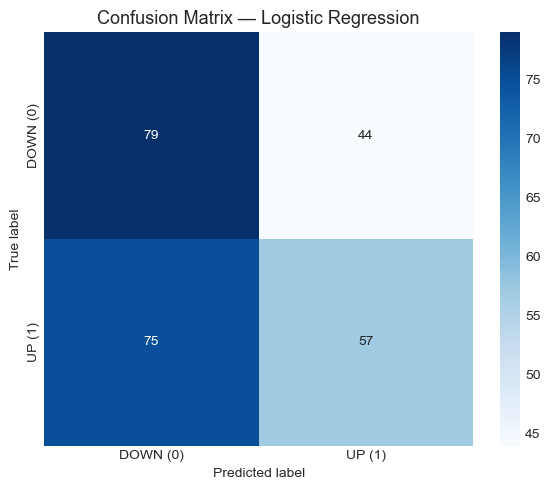

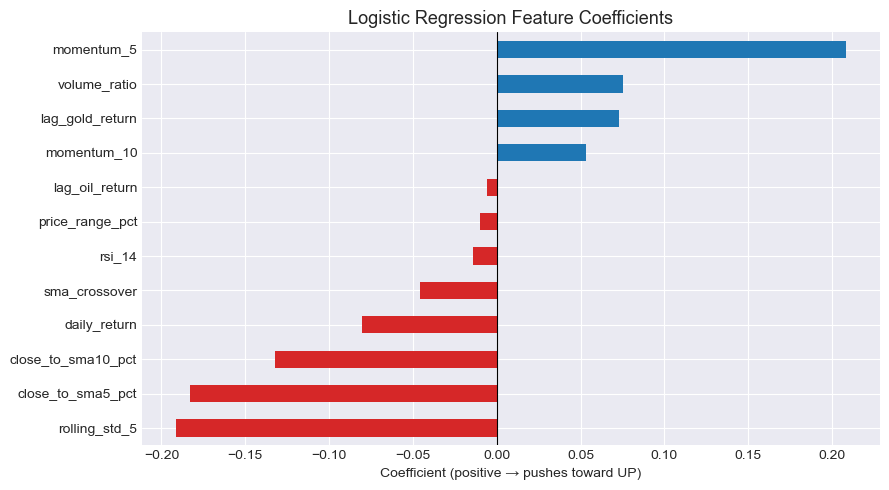

2026-05-20 16:49:59 | INFO | Logistic Regression saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\logistic_regression_lucan_it2.pkl


In [19]:
def train_logistic_regression(
    X_train: np.ndarray,
    y_train: pd.Series,
    random_state: int = 42,
) -> LogisticRegression:
    """Fit a logistic regression classifier with balanced class weights.

    Parameters
    ----------
    X_train : np.ndarray
        Scaled training features.
    y_train : pd.Series
        Binary training labels (0 = DOWN, 1 = UP).
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    LogisticRegression
        Fitted model.
    """
    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  # counteracts UP-class majority
        random_state=random_state,
    )
    model.fit(X_train, y_train)
    logger.info("Logistic Regression fitted.")
    return model


lr_model = train_logistic_regression(X_train_scaled, y_train, RANDOM_SEED)
y_pred_lr = lr_model.predict(X_test_scaled)
lr_metrics = evaluate_model(y_test, y_pred_lr, "Logistic Regression")

print(classification_report(y_test, y_pred_lr, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test, y_pred_lr, "Logistic Regression")

# Coefficient chart: positive value = pushes prediction toward UP
coef_df = pd.Series(lr_model.coef_[0], index=FEATURE_COLUMNS).sort_values()
fig, ax = plt.subplots(figsize=(9, 5))
coef_df.plot(
    kind="barh",
    ax=ax,
    color=["#d62728" if v < 0 else "#1f77b4" for v in coef_df],
)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Logistic Regression Feature Coefficients")
ax.set_xlabel("Coefficient (positive → pushes toward UP)")
plt.tight_layout()
plt.show()

lr_path = MODELS_DIR / "logistic_regression_lucan_it2.pkl"
joblib.dump(lr_model, lr_path)
logger.info("Logistic Regression saved to %s", lr_path)


### Interpretation

The coefficient chart shows which features push predictions toward UP (positive) or
DOWN (negative). `rsi_14` near 70+ typically generates a negative coefficient (overbought
→ mean reversion). `momentum_5` positive suggests the model captures short-term momentum
continuation. A linear model cannot capture interactions between features — that is the
motivation for the ensemble models in Sections 6 and 7.


---
## Section 6 — Iteration 2: Random Forest

**Changes from it1:** `max_depth=6` and `min_samples_leaf=5` prevent individual trees
from memorising the ~1000-row training set. `n_estimators=200` reduces ensemble variance.
`class_weight='balanced'` ensures DOWN-class samples carry equal total weight.


2026-05-20 16:49:59 | INFO | Random Forest fitted.
2026-05-20 16:49:59 | INFO | Random Forest  Acc=0.5137  Prec=0.5104  Rec=0.5137  F1=0.5058


              precision    recall  f1-score   support

        DOWN       0.49      0.38      0.43       123
          UP       0.53      0.64      0.58       132

    accuracy                           0.51       255
   macro avg       0.51      0.51      0.50       255
weighted avg       0.51      0.51      0.51       255



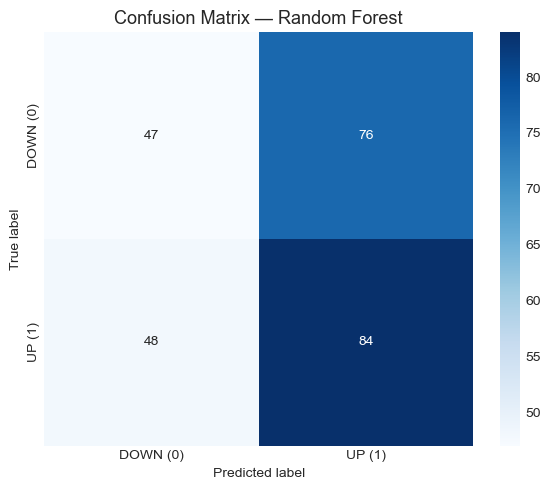

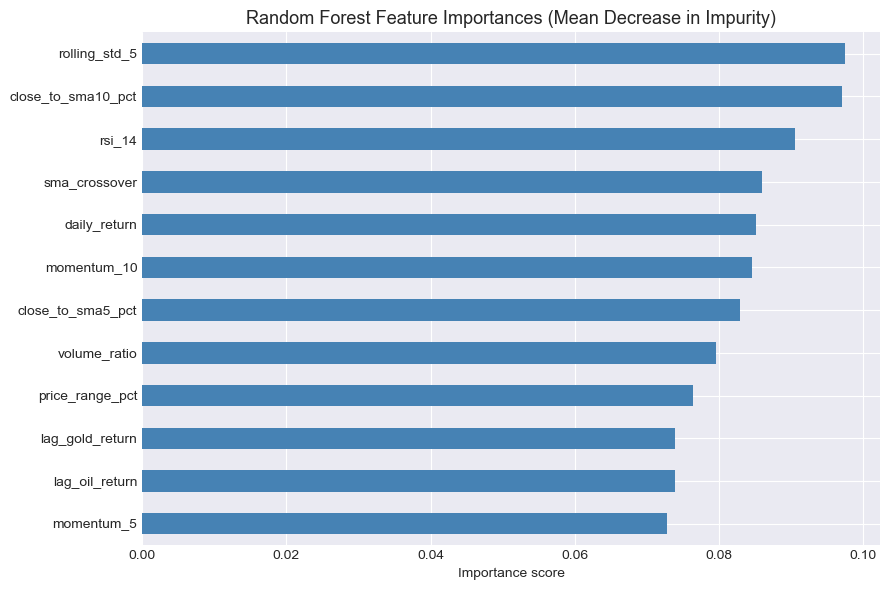

2026-05-20 16:50:00 | INFO | Random Forest saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\random_forest_lucan_it2.pkl


In [20]:
def train_random_forest(
    X_train: np.ndarray,
    y_train: pd.Series,
    random_state: int = 42,
) -> RandomForestClassifier:
    """Fit a Random Forest classifier with anti-overfitting hyperparameters.

    On a ~1000-row dataset, default settings (unlimited depth) produce trees
    that memorise training noise. Capping depth and raising min_samples_leaf
    forces each tree to learn more generalisable patterns.

    Parameters
    ----------
    X_train : np.ndarray
        Scaled training features.
    y_train : pd.Series
        Binary training labels.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    RandomForestClassifier
        Fitted model.
    """
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=6,
        min_samples_leaf=5,  # avoids overfitting on small training set
        class_weight="balanced",
        random_state=random_state,
    )
    model.fit(X_train, y_train)
    logger.info("Random Forest fitted.")
    return model


rf_model = train_random_forest(X_train_scaled, y_train, RANDOM_SEED)
y_pred_rf = rf_model.predict(X_test_scaled)
rf_metrics = evaluate_model(y_test, y_pred_rf, "Random Forest")

print(classification_report(y_test, y_pred_rf, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test, y_pred_rf, "Random Forest")

# Feature importance: mean decrease in impurity across all trees
importance_series = (
    pd.Series(rf_model.feature_importances_, index=FEATURE_COLUMNS)
    .sort_values(ascending=True)
)
fig, ax = plt.subplots(figsize=(9, 6))
importance_series.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("Random Forest Feature Importances (Mean Decrease in Impurity)")
ax.set_xlabel("Importance score")
plt.tight_layout()
plt.show()

rf_path = MODELS_DIR / "random_forest_lucan_it2.pkl"
joblib.dump(rf_model, rf_path)
logger.info("Random Forest saved to %s", rf_path)


---
## Section 7 — Iteration 3: XGBoost

**Changes from it1:** `subsample=0.8` and `colsample_bytree=0.8` introduce
stochastic regularisation. `scale_pos_weight` is computed as the ratio of
DOWN to UP samples, giving the minority class proportionally larger gradient signal.


2026-05-20 16:50:00 | INFO | XGBoost fitted (scale_pos_weight=0.807).
2026-05-20 16:50:00 | INFO | XGBoost  Acc=0.4549  Prec=0.4529  Rec=0.4549  F1=0.4530


              precision    recall  f1-score   support

        DOWN       0.43      0.39      0.41       123
          UP       0.48      0.52      0.49       132

    accuracy                           0.45       255
   macro avg       0.45      0.45      0.45       255
weighted avg       0.45      0.45      0.45       255



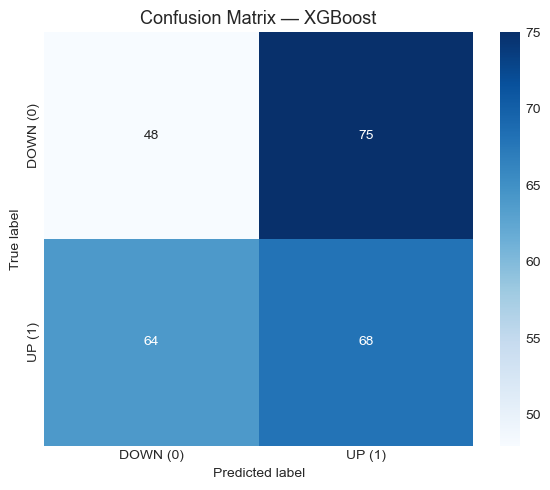

2026-05-20 16:50:00 | INFO | XGBoost saved to c:\Users\lucan\OneDrive - BUas\GitHub\2025-26d-fai1-adsai-group_15\models\lucan\xgboost_lucan_it2.pkl


In [21]:
def train_xgboost(
    X_train: np.ndarray,
    y_train: pd.Series,
    random_state: int = 42,
) -> XGBClassifier:
    """Fit an XGBoost classifier with stochastic regularisation.

    subsample and colsample_bytree add randomness per tree, reducing variance
    on this small dataset. scale_pos_weight compensates for class imbalance
    by up-weighting the DOWN (minority) class in the gradient computation.

    Parameters
    ----------
    X_train : np.ndarray
        Scaled training features.
    y_train : pd.Series
        Binary training labels.
    random_state : int
        Seed for reproducibility.

    Returns
    -------
    XGBClassifier
        Fitted model.
    """
    # Ratio of negative to positive samples for explicit class balancing
    n_down = int((y_train == 0).sum())
    n_up = int((y_train == 1).sum())
    spw = n_down / n_up

    _xgb_major = int(xgb_lib.__version__.split(".")[0])
    params = dict(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,        # row subsampling per tree
        colsample_bytree=0.8, # feature subsampling per tree
        scale_pos_weight=spw,
        eval_metric="logloss",
        random_state=random_state,
    )
    if _xgb_major < 2:
        params["use_label_encoder"] = False

    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    logger.info("XGBoost fitted (scale_pos_weight=%.3f).", spw)
    return model


xgb_model = train_xgboost(X_train_scaled, y_train, RANDOM_SEED)
y_pred_xgb = xgb_model.predict(X_test_scaled)
xgb_metrics = evaluate_model(y_test, y_pred_xgb, "XGBoost")

print(classification_report(y_test, y_pred_xgb, target_names=["DOWN", "UP"]))
plot_confusion_matrix(y_test, y_pred_xgb, "XGBoost")

xgb_path = MODELS_DIR / "xgboost_lucan_it2.pkl"
joblib.dump(xgb_model, xgb_path)
logger.info("XGBoost saved to %s", xgb_path)


---
## Section 8 — Model Comparison

**F1 (weighted)** is the primary metric because it balances precision and recall.
Both error types carry financial consequences: a false positive (pred UP, actual DOWN)
means buying into a losing day; a false negative (pred DOWN, actual UP) means missing
a profitable day.


                    Model  Accuracy  Precision  Recall     F1
Baseline (Majority Class)    0.5176     0.2680  0.5176 0.3531
      Logistic Regression    0.5333     0.5396  0.5333 0.5284
            Random Forest    0.5137     0.5104  0.5137 0.5058
                  XGBoost    0.4549     0.4529  0.4549 0.4530


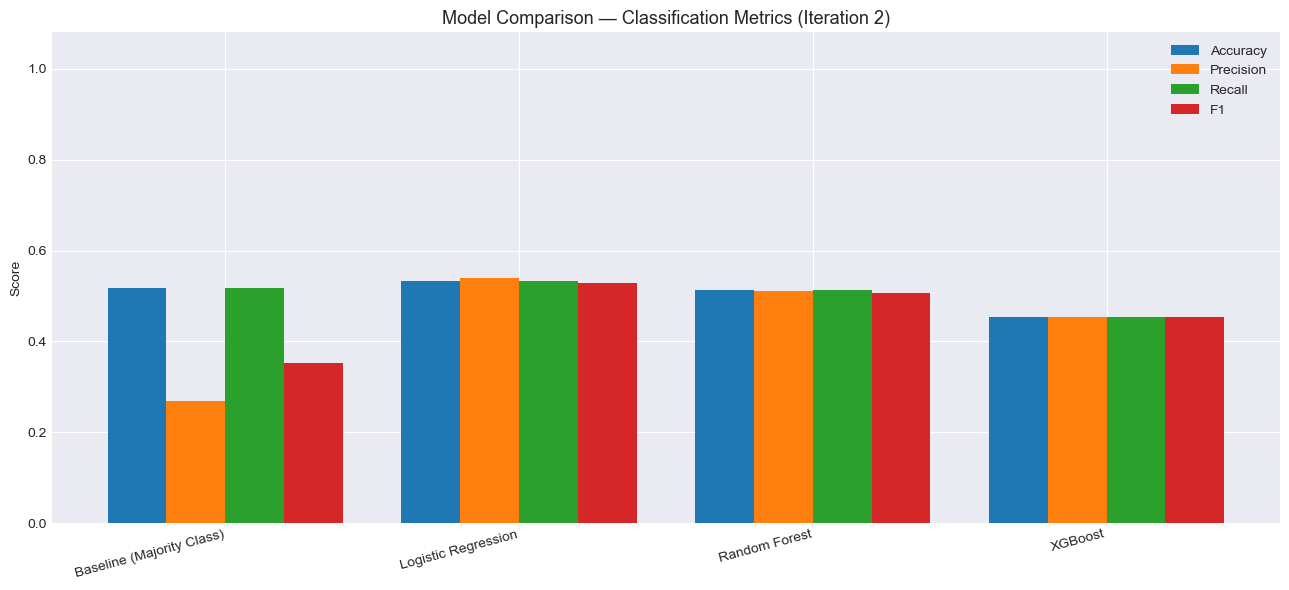

2026-05-20 16:50:00 | INFO | Best model by F1: Logistic Regression (F1=0.5284)



Best model: Logistic Regression   F1 = 0.5284


In [22]:
results_df = pd.DataFrame([
    baseline_metrics,
    lr_metrics,
    rf_metrics,
    xgb_metrics,
])
print(results_df.to_string(index=False))

# Grouped bar chart comparing all four metrics across models
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1"]
x = np.arange(len(results_df))
width = 0.20

fig, ax = plt.subplots(figsize=(13, 6))
for i, metric in enumerate(metrics_to_plot):
    ax.bar(x + i * width, results_df[metric], width, label=metric)

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df["Model"], rotation=15, ha="right")
ax.set_ylim(0, 1.08)
ax.set_ylabel("Score")
ax.set_title("Model Comparison — Classification Metrics (Iteration 2)")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

# Select the best model by weighted F1
best_row = results_df.loc[results_df["F1"].idxmax()]
BEST_MODEL_NAME: str = best_row["Model"]
logger.info("Best model by F1: %s (F1=%.4f)", BEST_MODEL_NAME, best_row["F1"])
print(f"\nBest model: {BEST_MODEL_NAME}   F1 = {best_row['F1']:.4f}")


---
## Section 9 — Error Analysis

Temporal error overlay reveals whether errors cluster around specific market regimes
(high-volatility periods, structural breaks) or are randomly distributed.
Clustered errors suggest regime sensitivity; random errors are more manageable.


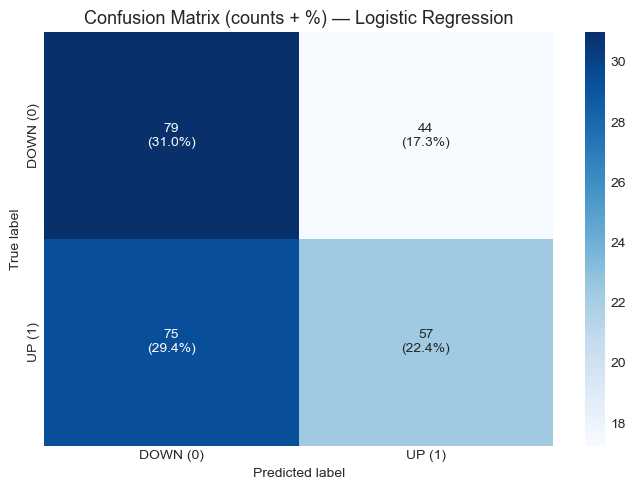

2026-05-20 16:50:00 | INFO | False positives (pred UP, actual DOWN): 44
2026-05-20 16:50:00 | INFO | False negatives (pred DOWN, actual UP): 75


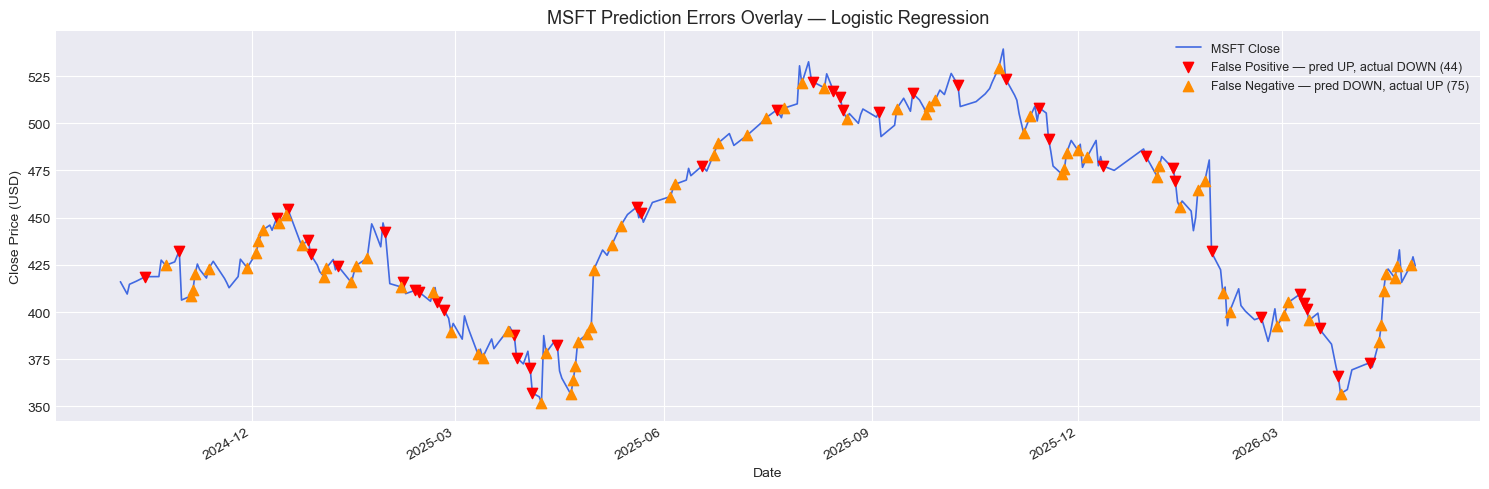

In [23]:
_model_preds = {
    "Baseline (Majority Class)": y_pred_dummy,
    "Logistic Regression": y_pred_lr,
    "Random Forest": y_pred_rf,
    "XGBoost": y_pred_xgb,
}
y_pred_best = _model_preds[BEST_MODEL_NAME]

# Confusion matrix with both raw counts and row percentages
cm = confusion_matrix(y_test, y_pred_best)
cm_pct = cm.astype(float) / cm.sum() * 100
annot = np.array([
    [f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)" for j in range(cm.shape[1])]
    for i in range(cm.shape[0])
])

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm_pct, annot=annot, fmt="", cmap="Blues",
    xticklabels=["DOWN (0)", "UP (1)"],
    yticklabels=["DOWN (0)", "UP (1)"],
    ax=ax,
)
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title(f"Confusion Matrix (counts + %) — {BEST_MODEL_NAME}")
plt.tight_layout()
plt.show()

# Locate prediction errors in the test set
y_pred_series = pd.Series(y_pred_best, index=df_test.index, name="pred")
false_pos = df_test.index[(y_pred_series == 1) & (y_test == 0)]
false_neg = df_test.index[(y_pred_series == 0) & (y_test == 1)]

logger.info("False positives (pred UP, actual DOWN): %d", len(false_pos))
logger.info("False negatives (pred DOWN, actual UP): %d", len(false_neg))

# Overlay errors on the MSFT price chart
close_col = _detect_column(df, ["close", "msft_close", "adj close", "adj_close"])

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(
    df_test.index, df_test[close_col],
    color="royalblue", linewidth=1.2, label="MSFT Close",
)
ax.scatter(
    false_pos, df_test.loc[false_pos, close_col],
    color="red", marker="v", s=55, zorder=5,
    label=f"False Positive — pred UP, actual DOWN ({len(false_pos)})",
)
ax.scatter(
    false_neg, df_test.loc[false_neg, close_col],
    color="darkorange", marker="^", s=55, zorder=5,
    label=f"False Negative — pred DOWN, actual UP ({len(false_neg)})",
)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
fig.autofmt_xdate(rotation=30)
ax.set_xlabel("Date")
ax.set_ylabel("Close Price (USD)")
ax.set_title(f"MSFT Prediction Errors Overlay — {BEST_MODEL_NAME}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Section 10 — TimeSeriesSplit Cross-Validation

`TimeSeriesSplit` preserves chronological order — each fold's training set ends
**before** its test set begins. `StratifiedKFold` would shuffle the data, creating
lookahead bias and producing optimistic metrics unrepresentative of production.

The `Pipeline` inside `run_cross_validation` ensures the scaler is re-fitted on each
fold's training portion only, preventing any test-fold statistics from leaking in.


2026-05-20 16:50:00 | INFO | TimeSeriesSplit CV (5 folds)  mean=0.4996  std=0.0185


F1 per fold : [0.515, 0.4844, 0.4811, 0.4897, 0.5278]
Mean F1     : 0.4996
Std dev     : 0.0185


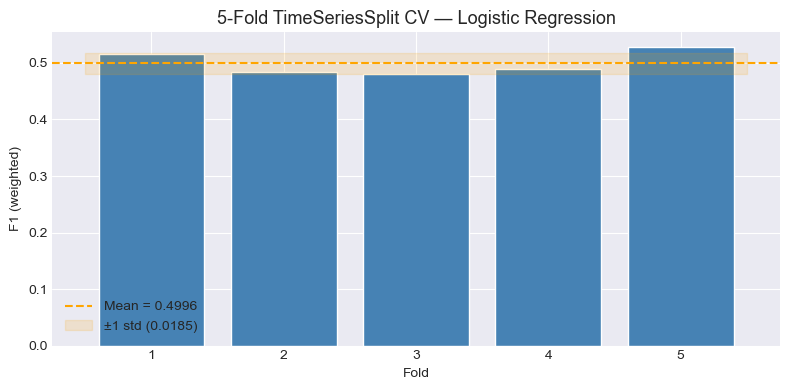

In [24]:
def run_cross_validation(
    model,
    X: pd.DataFrame,
    y: pd.Series,
    n_splits: int = 5,
    scoring: str = "f1_weighted",
) -> np.ndarray:
    """TimeSeriesSplit cross-validation with per-fold RobustScaler.

    Parameters
    ----------
    model : estimator
        Scikit-learn compatible model (cloned per fold, not modified in place).
    X : pd.DataFrame
        Unscaled feature matrix.
    y : pd.Series
        Target labels.
    n_splits : int
        Number of TimeSeriesSplit folds.
    scoring : str
        Scikit-learn metric name.

    Returns
    -------
    np.ndarray
        Per-fold scores.
    """
    # Pipeline re-fits scaler on each fold's training data to prevent leakage
    cv_pipeline = Pipeline([
        ("scaler", RobustScaler()),
        ("model", clone(model)),
    ])
    tscv = TimeSeriesSplit(n_splits=n_splits)
    scores = cross_val_score(cv_pipeline, X, y, cv=tscv, scoring=scoring)
    logger.info(
        "TimeSeriesSplit CV (%d folds)  mean=%.4f  std=%.4f",
        n_splits, scores.mean(), scores.std(),
    )
    return scores


_model_objs = {
    "Baseline (Majority Class)": dummy,
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
}
best_model_obj = _model_objs[BEST_MODEL_NAME]

cv_scores = run_cross_validation(best_model_obj, df[FEATURE_COLUMNS], df["target"])

print(f"F1 per fold : {[round(float(s), 4) for s in cv_scores]}")
print(f"Mean F1     : {cv_scores.mean():.4f}")
print(f"Std dev     : {cv_scores.std():.4f}")

# Bar chart with mean line and ±1 std band
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(cv_scores) + 1), cv_scores, color="steelblue", edgecolor="white")
ax.axhline(
    cv_scores.mean(), color="orange", linestyle="--", linewidth=1.5,
    label=f"Mean = {cv_scores.mean():.4f}",
)
ax.fill_between(
    [0.5, len(cv_scores) + 0.5],
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.15, color="orange",
    label=f"±1 std ({cv_scores.std():.4f})",
)
ax.set_xlabel("Fold")
ax.set_ylabel("F1 (weighted)")
ax.set_title(f"5-Fold TimeSeriesSplit CV — {BEST_MODEL_NAME}")
ax.set_xticks(range(1, len(cv_scores) + 1))
ax.legend()
plt.tight_layout()
plt.show()


---
## Section 11 — Business Value Interpretation

### What the model predicts and for whom

This model predicts the **binary next-day direction** of MSFT's closing price
(UP or DOWN, excluding ±0.5% neutral days). It is designed for **retail investors**
using the MSFT Forecaster dashboard as a decision-support tool — not an
automated trading system.

### Interpreting the metrics

| F1 Range | Practical meaning |
|---|---|
| < 0.50 | Worse than a coin flip on this balanced problem — no deployable value |
| 0.50–0.55 | Marginal signal; use only as one factor among many |
| 0.55–0.65 | Genuine directional signal; useful supporting indicator |
| > 0.65 | Strong signal; can justify more weight in a decision framework |

### Limitations

| Limitation | Impact |
|---|---|
| No retraining schedule | Performance degrades as market regimes shift |
| MSFT only | Does not generalise to other stocks without retraining |
| End-of-day data only | Intraday signals and pre-market moves are ignored |
| Earnings / macro events not included | Model is blind to known catalyst dates |
| Neutral days excluded (~25 % of days) | Dashboard must show "no signal" state clearly |

### Dashboard integration

The saved `scaler.pkl` and best-model `.pkl` allow the Streamlit dashboard to:
1. Load both at startup with `joblib.load()`.
2. Compute the same `FEATURE_COLUMNS` from today's OHLCV + macro data.
3. Call `model.predict_proba()` to return a confidence score alongside the direction.
4. Display the prediction with an explicit disclaimer that this is not financial advice.
